## LangGraph Open Deep Research - Supervisor-Researcher Architecture

In this notebook, we'll explore the **supervisor-researcher delegation architecture** for conducting deep research with LangGraph.

You can visit this repository to see the original application: [Open Deep Research](https://github.com/langchain-ai/open_deep_research)

Let's jump in!

## What We're Building

This implementation uses a **hierarchical delegation pattern** where:

1. **User Clarification** - Optionally asks clarifying questions to understand the research scope
2. **Research Brief Generation** - Transforms user messages into a structured research brief
3. **Supervisor** - A lead researcher that analyzes the brief and delegates research tasks
4. **Parallel Researchers** - Multiple sub-agents that conduct focused research simultaneously
5. **Research Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings are combined into a comprehensive report

![Architecture Diagram](https://private-user-images.githubusercontent.com/181020547/465824799-12a2371b-8be2-4219-9b48-90503eb43c69.png?jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbSIsImtleSI6ImtleTUiLCJleHAiOjE3NjAwNDgyMzcsIm5iZiI6MTc2MDA0NzkzNywicGF0aCI6Ii8xODEwMjA1NDcvNDY1ODI0Nzk5LTEyYTIzNzFiLThiZTItNDIxOS05YjQ4LTkwNTAzZWI0M2M2OS5wbmc_WC1BbXotQWxnb3JpdGhtPUFXUzQtSE1BQy1TSEEyNTYmWC1BbXotQ3JlZGVudGlhbD1BS0lBVkNPRFlMU0E1M1BRSzRaQSUyRjIwMjUxMDA5JTJGdXMtZWFzdC0xJTJGczMlMkZhd3M0X3JlcXVlc3QmWC1BbXotRGF0ZT0yMDI1MTAwOVQyMjEyMTdaJlgtQW16LUV4cGlyZXM9MzAwJlgtQW16LVNpZ25hdHVyZT1iYTRmYTAzYjkzYjA2MGE4ZTZlYjQ4ODU1OWIwY2VlZWU0Mzk0YzdmMjQ1YTlhMDMyNmI3NWNlZTQxNDdlZGViJlgtQW16LVNpZ25lZEhlYWRlcnM9aG9zdCJ9.a8477QD1J4Lrmys7jB8gt_H5pdiKBsKsu3npEqZjEpo)

This differs from a section-based approach by allowing dynamic task decomposition based on the research question, rather than predefined sections.

## Dependencies

You'll need API keys for Anthropic (for the LLM) and Tavily (for web search). We'll configure the system to use Anthropic's Claude Sonnet 4 exclusively.

In [3]:
import os
import getpass

os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your Anthropic API key: ")
os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

## Task 1: State Definitions

The state structure is hierarchical with three levels:

### Agent State (Top Level)
Contains the overall conversation messages, research brief, accumulated notes, and final report.

### Supervisor State (Middle Level)
Manages the research supervisor's messages, research iterations, and coordinating parallel researchers.

### Researcher State (Bottom Level)
Each individual researcher has their own message history, tool call iterations, and research findings.

We also have structured outputs for tool calling:
- **ConductResearch** - Tool for supervisor to delegate research to a sub-agent
- **ResearchComplete** - Tool to signal research phase is done
- **ClarifyWithUser** - Structured output for asking clarifying questions
- **ResearchQuestion** - Structured output for the research brief

Let's import these from our library: [`open_deep_library/state.py`](open_deep_library/state.py)

In [4]:
# Import state definitions from the library
from open_deep_library.state import (
    # Main workflow states
    AgentState,           # Lines 65-72: Top-level agent state with messages, research_brief, notes, final_report
    AgentInputState,      # Lines 62-63: Input state is just messages
    
    # Supervisor states
    SupervisorState,      # Lines 74-81: Supervisor manages research delegation and iterations
    
    # Researcher states
    ResearcherState,      # Lines 83-90: Individual researcher with messages and tool iterations
    ResearcherOutputState, # Lines 92-96: Output from researcher (compressed research + raw notes)
    
    # Structured outputs for tool calling
    ConductResearch,      # Lines 15-19: Tool for delegating research to sub-agents
    ResearchComplete,     # Lines 21-22: Tool to signal research completion
    ClarifyWithUser,      # Lines 30-41: Structured output for user clarification
    ResearchQuestion,     # Lines 43-48: Structured output for research brief
)

#### ❓ Question 1:

 Explain the interrelationships between the three states.  Why don't we just make a single huge state?

## Task 2: Utility Functions and Tools

The system uses several key utilities:

### Search Tools
- **tavily_search** - Async web search with automatic summarization to stay within token limits
- Supports Anthropic native web search and Tavily API

### Reflection Tools
- **think_tool** - Allows researchers to reflect on their progress and plan next steps (ReAct pattern)

### Helper Utilities
- **get_all_tools** - Assembles the complete toolkit (search + MCP + reflection)
- **get_today_str** - Provides current date context for research
- Token limit handling utilities for graceful degradation

These are defined in [`open_deep_library/utils.py`](open_deep_library/utils.py)

In [5]:
# Import utility functions and tools from the library
from open_deep_library.utils import (
    # Search tool - Lines 43-136: Tavily search with automatic summarization
    tavily_search,
    
    # Reflection tool - Lines 219-244: Strategic thinking tool for ReAct pattern
    think_tool,
    
    # Tool assembly - Lines 569-597: Get all configured tools
    get_all_tools,
    
    # Date utility - Lines 872-879: Get formatted current date
    get_today_str,
    
    # Supporting utilities for error handling
    get_api_key_for_model,          # Lines 892-914: Get API keys from config or env
    is_token_limit_exceeded,         # Lines 665-701: Detect token limit errors
    get_model_token_limit,           # Lines 831-846: Look up model's token limit
    remove_up_to_last_ai_message,    # Lines 848-866: Truncate messages for retry
    anthropic_websearch_called,      # Lines 607-637: Detect Anthropic native search usage
    openai_websearch_called,         # Lines 639-658: Detect OpenAI native search usage
    get_notes_from_tool_calls,       # Lines 599-601: Extract notes from tool messages
)

### ❓ Question 2:  

What are the advantages and disadvantages of importing these components instead of including them in the notebook?

## Task 3: Configuration System

The configuration system controls:

### Research Behavior
- **allow_clarification** - Whether to ask clarifying questions before research
- **max_concurrent_research_units** - How many parallel researchers can run (default: 5)
- **max_researcher_iterations** - How many times supervisor can delegate research (default: 6)
- **max_react_tool_calls** - Tool call limit per researcher (default: 10)

### Model Configuration
- **research_model** - Model for research and supervision (we'll use Anthropic)
- **compression_model** - Model for synthesizing findings
- **final_report_model** - Model for writing the final report
- **summarization_model** - Model for summarizing web search results

### Search Configuration
- **search_api** - Which search API to use (ANTHROPIC, TAVILY, or NONE)
- **max_content_length** - Character limit before summarization

Defined in [`open_deep_library/configuration.py`](open_deep_library/configuration.py)

In [6]:
# Import configuration from the library
from open_deep_library.configuration import (
    Configuration,    # Lines 38-247: Main configuration class with all settings
    SearchAPI,        # Lines 11-17: Enum for search API options (ANTHROPIC, TAVILY, NONE)
)

## Task 4: Prompt Templates

The system uses carefully engineered prompts for each phase:

### Phase 1: Clarification
**clarify_with_user_instructions** - Analyzes if the research scope is clear or needs clarification

### Phase 2: Research Brief
**transform_messages_into_research_topic_prompt** - Converts user messages into a detailed research brief

### Phase 3: Supervisor
**lead_researcher_prompt** - System prompt for the supervisor that manages delegation strategy

### Phase 4: Researcher
**research_system_prompt** - System prompt for individual researchers conducting focused research

### Phase 5: Compression
**compress_research_system_prompt** - Prompt for synthesizing research findings without losing information

### Phase 6: Final Report
**final_report_generation_prompt** - Comprehensive prompt for writing the final report

All prompts are defined in [`open_deep_library/prompts.py`](open_deep_library/prompts.py)

In [7]:
# Import prompt templates from the library
from open_deep_library.prompts import (
    clarify_with_user_instructions,                    # Lines 3-41: Ask clarifying questions
    transform_messages_into_research_topic_prompt,     # Lines 44-77: Generate research brief
    lead_researcher_prompt,                            # Lines 79-136: Supervisor system prompt
    research_system_prompt,                            # Lines 138-183: Researcher system prompt
    compress_research_system_prompt,                   # Lines 186-222: Research compression prompt
    final_report_generation_prompt,                    # Lines 228-308: Final report generation
)

## Task 5: Node Functions - The Building Blocks

Now let's look at the node functions that make up our graph. We'll import them from the library and understand what each does.

### The Complete Research Workflow

The workflow consists of 8 key nodes organized into 3 subgraphs:

1. **Main Graph Nodes:**
   - `clarify_with_user` - Entry point that checks if clarification is needed
   - `write_research_brief` - Transforms user input into structured research brief
   - `final_report_generation` - Synthesizes all research into final report

2. **Supervisor Subgraph Nodes:**
   - `supervisor` - Lead researcher that plans and delegates
   - `supervisor_tools` - Executes supervisor's tool calls (delegation, reflection)

3. **Researcher Subgraph Nodes:**
   - `researcher` - Individual researcher conducting focused research
   - `researcher_tools` - Executes researcher's tool calls (search, reflection)
   - `compress_research` - Synthesizes researcher's findings

All nodes are defined in [`open_deep_library/deep_researcher.py`](open_deep_library/deep_researcher.py)

### Node 1: clarify_with_user

**Purpose:** Analyzes user messages and asks clarifying questions if the research scope is unclear.

**Key Steps:**
1. Check if clarification is enabled in configuration
2. Use structured output to analyze if clarification is needed
3. If needed, end with a clarifying question for the user
4. If not needed, proceed to research brief with verification message

**Implementation:** [`open_deep_library/deep_researcher.py` lines 60-115](open_deep_library/deep_researcher.py#L60-L115)

In [8]:
# Import the clarify_with_user node
from open_deep_library.deep_researcher import clarify_with_user

### Node 2: write_research_brief

**Purpose:** Transforms user messages into a structured research brief for the supervisor.

**Key Steps:**
1. Use structured output to generate detailed research brief from messages
2. Initialize supervisor with system prompt and research brief
3. Set up supervisor messages with proper context

**Why this matters:** A well-structured research brief helps the supervisor make better delegation decisions.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 118-175](open_deep_library/deep_researcher.py#L118-L175)

In [9]:
# Import the write_research_brief node
from open_deep_library.deep_researcher import write_research_brief

### Node 3: supervisor

**Purpose:** Lead research supervisor that plans research strategy and delegates to sub-researchers.

**Key Steps:**
1. Configure model with three tools:
   - `ConductResearch` - Delegate research to a sub-agent
   - `ResearchComplete` - Signal that research is done
   - `think_tool` - Strategic reflection before decisions
2. Generate response based on current context
3. Increment research iteration count
4. Proceed to tool execution

**Decision Making:** The supervisor uses `think_tool` to reflect before delegating research, ensuring thoughtful decomposition of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 178-223](open_deep_library/deep_researcher.py#L178-L223)

In [10]:
# Import the supervisor node (from supervisor subgraph)
from open_deep_library.deep_researcher import supervisor

### Node 4: supervisor_tools

**Purpose:** Executes the supervisor's tool calls, including strategic thinking and research delegation.

**Key Steps:**
1. Check exit conditions:
   - Exceeded maximum iterations
   - No tool calls made
   - `ResearchComplete` called
2. Process `think_tool` calls for strategic reflection
3. Execute `ConductResearch` calls in parallel:
   - Spawn researcher subgraphs for each delegation
   - Limit to `max_concurrent_research_units` (default: 5)
   - Gather all results asynchronously
4. Aggregate findings and return to supervisor

**Parallel Execution:** This is where the magic happens - multiple researchers work simultaneously on different aspects of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 225-349](open_deep_library/deep_researcher.py#L225-L349)

In [11]:
# Import the supervisor_tools node
from open_deep_library.deep_researcher import supervisor_tools

### Node 5: researcher

**Purpose:** Individual researcher that conducts focused research on a specific topic.

**Key Steps:**
1. Load all available tools (search, MCP, reflection)
2. Configure model with tools and researcher system prompt
3. Generate response with tool calls
4. Increment tool call iteration count

**ReAct Pattern:** Researchers use `think_tool` to reflect after each search, deciding whether to continue or provide their answer.

**Available Tools:**
- Search tools (Tavily or Anthropic native search)
- `think_tool` for strategic reflection
- `ResearchComplete` to signal completion
- MCP tools (if configured)

**Implementation:** [`open_deep_library/deep_researcher.py` lines 365-424](open_deep_library/deep_researcher.py#L365-L424)

In [12]:
# Import the researcher node (from researcher subgraph)
from open_deep_library.deep_researcher import researcher

### Node 6: researcher_tools

**Purpose:** Executes the researcher's tool calls, including searches and strategic reflection.

**Key Steps:**
1. Check early exit conditions (no tool calls, native search used)
2. Execute all tool calls in parallel:
   - Search tools fetch and summarize web content
   - `think_tool` records strategic reflections
   - MCP tools execute external integrations
3. Check late exit conditions:
   - Exceeded `max_react_tool_calls` (default: 10)
   - `ResearchComplete` called
4. Continue research loop or proceed to compression

**Error Handling:** Safely handles tool execution errors and continues with available results.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 435-509](open_deep_library/deep_researcher.py#L435-L509)

In [13]:
# Import the researcher_tools node
from open_deep_library.deep_researcher import researcher_tools

### Node 7: compress_research

**Purpose:** Compresses and synthesizes research findings into a concise, structured summary.

**Key Steps:**
1. Configure compression model
2. Add compression instruction to messages
3. Attempt compression with retry logic:
   - If token limit exceeded, remove older messages
   - Retry up to 3 times
4. Extract raw notes from tool and AI messages
5. Return compressed research and raw notes

**Why Compression?** Researchers may accumulate lots of tool outputs and reflections. Compression ensures:
- All important information is preserved
- Redundant information is deduplicated
- Content stays within token limits for the final report

**Token Limit Handling:** Gracefully handles token limit errors by progressively truncating messages.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 511-585](open_deep_library/deep_researcher.py#L511-L585)

In [14]:
# Import the compress_research node
from open_deep_library.deep_researcher import compress_research

### Node 8: final_report_generation

**Purpose:** Generates the final comprehensive research report from all collected findings.

**Key Steps:**
1. Extract all notes from completed research
2. Configure final report model
3. Attempt report generation with retry logic:
   - If token limit exceeded, truncate findings by 10%
   - Retry up to 3 times
4. Return final report or error message

**Token Limit Strategy:**
- First retry: Use model's token limit × 4 as character limit
- Subsequent retries: Reduce by 10% each time
- Graceful degradation with helpful error messages

**Report Quality:** The prompt guides the model to create well-structured reports with:
- Proper headings and sections
- Inline citations
- Comprehensive coverage of all findings
- Sources section at the end

**Implementation:** [`open_deep_library/deep_researcher.py` lines 607-697](open_deep_library/deep_researcher.py#L607-L697)

In [15]:
# Import the final_report_generation node
from open_deep_library.deep_researcher import final_report_generation

## Task 6: Graph Construction - Putting It All Together

The system is organized into three interconnected graphs:

### 1. Researcher Subgraph (Bottom Level)
Handles individual focused research on a specific topic:
```
START → researcher → researcher_tools → compress_research → END
               ↑            ↓
               └────────────┘ (loops until max iterations or ResearchComplete)
```

### 2. Supervisor Subgraph (Middle Level)
Manages research delegation and coordination:
```
START → supervisor → supervisor_tools → END
            ↑              ↓
            └──────────────┘ (loops until max iterations or ResearchComplete)
            
supervisor_tools spawns multiple researcher_subgraphs in parallel
```

### 3. Main Deep Researcher Graph (Top Level)
Orchestrates the complete research workflow:
```
START → clarify_with_user → write_research_brief → research_supervisor → final_report_generation → END
                 ↓                                       (supervisor_subgraph)
               (may end early if clarification needed)
```

Let's import the compiled graphs from the library.

In [16]:
# Import the pre-compiled graphs from the library
from open_deep_library.deep_researcher import (
    # Bottom level: Individual researcher workflow
    researcher_subgraph,    # Lines 588-605: researcher → researcher_tools → compress_research
    
    # Middle level: Supervisor coordination
    supervisor_subgraph,    # Lines 351-363: supervisor → supervisor_tools (spawns researchers)
    
    # Top level: Complete research workflow
    deep_researcher,        # Lines 699-719: Main graph with all phases
)

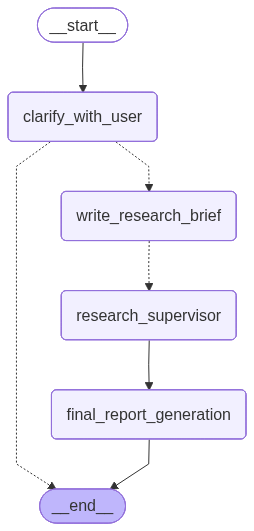

In [21]:
deep_researcher

## Why This Architecture?

### Advantages of Supervisor-Researcher Delegation

1. **Dynamic Task Decomposition**
   - Unlike section-based approaches with predefined structure, the supervisor can break down research based on the actual question
   - Adapts to different types of research (comparisons, lists, deep dives, etc.)

2. **Parallel Execution**
   - Multiple researchers work simultaneously on different aspects
   - Much faster than sequential section processing
   - Configurable parallelism (1-20 concurrent researchers)

3. **ReAct Pattern for Quality**
   - Researchers use `think_tool` to reflect after each search
   - Prevents excessive searching and improves search quality
   - Natural stopping conditions based on information sufficiency

4. **Flexible Tool Integration**
   - Easy to add MCP tools for specialized research
   - Supports multiple search APIs (Anthropic, Tavily)
   - Each researcher can use different tool combinations

5. **Graceful Token Limit Handling**
   - Compression prevents token overflow
   - Progressive truncation in final report generation
   - Research can scale to arbitrary depths

### Trade-offs

- **Complexity:** More moving parts than section-based approach
- **Cost:** Parallel researchers use more tokens (but faster)
- **Unpredictability:** Research structure emerges dynamically

## Task 7: Running the Deep Researcher

Now let's see the system in action! We'll use it to analyze a PDF document about how people use AI.

### Setup

We need to:
1. Load the PDF document
2. Configure the execution with Anthropic settings
3. Run the research workflow

In [17]:
# Load the PDF document
from pathlib import Path
import PyPDF2

def load_pdf(pdf_path: str) -> str:
    """Load and extract text from PDF."""
    pdf_text = ""
    with open(pdf_path, 'rb') as file:
        pdf_reader = PyPDF2.PdfReader(file)
        for page in pdf_reader.pages:
            pdf_text += page.extract_text() + "\n\n"
    return pdf_text

# Load the PDF about how people use AI
pdf_path = "data/howpeopleuseai.pdf"
pdf_content = load_pdf(pdf_path)

print(f"Loaded PDF with {len(pdf_content)} characters")
print(f"First 500 characters:\n{pdf_content[:500]}...")

Loaded PDF with 112460 characters
First 500 characters:
NBER WORKING PAPER SERIES
HOW PEOPLE USE CHATGPT
Aaron Chatterji
Thomas Cunningham
David J. Deming
Zoe Hitzig
Christopher Ong
Carl Yan Shan
Kevin Wadman
Working Paper 34255
http://www.nber.org/papers/w34255
NATIONAL BUREAU OF ECONOMIC RESEARCH
1050 Massachusetts Avenue
Cambridge, MA 02138
September 2025
We acknowledge help and comments from Joshua Achiam, Hemanth Asirvatham, Ryan 
Beiermeister,  Rachel Brown, Cassandra Duchan Solis, Jason Kwon, Elliott Mokski, Kevin Rao, 
Harrison Satcher,  Gawe...


In [18]:
# Set up the graph with Anthropic configuration
from IPython.display import Markdown, display
import uuid

# Note: deep_researcher is already compiled from the library
# For this demo, we'll use it directly without additional checkpointing
graph = deep_researcher

print("✓ Graph ready for execution")
print("  (Note: The graph is pre-compiled from the library)")

✓ Graph ready for execution
  (Note: The graph is pre-compiled from the library)


### Configuration for Anthropic

We'll configure the system to use:
- **Claude Sonnet 4** for all research, supervision, and report generation
- **Tavily** for web search (you can also use Anthropic's native search)
- **Moderate parallelism** (3 concurrent researchers)
- **Clarification enabled** (will ask if research scope is unclear)

In [19]:
# Configure for Anthropic with moderate settings
config = {
    "configurable": {
        # Model configuration - using Claude Sonnet 4 for everything
        "research_model": "anthropic:claude-sonnet-4-20250514",
        "research_model_max_tokens": 10000,
        
        "compression_model": "anthropic:claude-sonnet-4-20250514",
        "compression_model_max_tokens": 8192,
        
        "final_report_model": "anthropic:claude-sonnet-4-20250514",
        "final_report_model_max_tokens": 10000,
        
        "summarization_model": "anthropic:claude-sonnet-4-20250514",
        "summarization_model_max_tokens": 8192,
        
        # Research behavior
        "allow_clarification": True,
        "max_concurrent_research_units": 1,  # 1 parallel researchers
        "max_researcher_iterations": 2,      # Supervisor can delegate up to 2 times
        "max_react_tool_calls": 3,           # Each researcher can make up to 3 tool calls
        
        # Search configuration
        "search_api": "tavily",  # Using Tavily for web search
        "max_content_length": 50000,
        
        # Thread ID for this conversation
        "thread_id": str(uuid.uuid4())
    }
}

print("✓ Configuration ready")
print(f"  - Research Model: Claude Sonnet 4")
print(f"  - Max Concurrent Researchers: 3")
print(f"  - Max Iterations: 4")
print(f"  - Search API: Tavily")

✓ Configuration ready
  - Research Model: Claude Sonnet 4
  - Max Concurrent Researchers: 3
  - Max Iterations: 4
  - Search API: Tavily


### Execute the Research

Now let's run the research! We'll ask the system to analyze the PDF and provide insights about how people use AI.

The workflow will:
1. **Clarify** - Check if the request is clear (may skip if obvious)
2. **Research Brief** - Transform our request into a structured brief
3. **Supervisor** - Plan research strategy and delegate to researchers
4. **Parallel Research** - Multiple researchers gather information simultaneously
5. **Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings combined into comprehensive report

In [20]:
# Create our research request with PDF context
research_request = f"""
I have a PDF document about how people use AI. Please analyze this document and provide insights about:

1. What are the main findings about how people are using AI?
2. What are the most common use cases?
3. What trends or patterns emerge from the data?

Here's the PDF content:

{pdf_content[:10000]}  # First 10k chars to stay within limits

...[content truncated for context window]
"""

# Execute the graph
async def run_research():
    """Run the research workflow and display results."""
    print("Starting research workflow...\n")
    
    async for event in graph.astream(
        {"messages": [{"role": "user", "content": research_request}]},
        config,
        stream_mode="updates"
    ):
        # Display each step
        for node_name, node_output in event.items():
            print(f"\n{'='*60}")
            print(f"Node: {node_name}")
            print(f"{'='*60}")
            
            if node_name == "clarify_with_user":
                if "messages" in node_output:
                    last_msg = node_output["messages"][-1]
                    print(f"\n{last_msg.content}")
            
            elif node_name == "write_research_brief":
                if "research_brief" in node_output:
                    print(f"\nResearch Brief Generated:")
                    print(f"{node_output['research_brief'][:500]}...")
            
            elif node_name == "supervisor":
                print(f"\nSupervisor planning research strategy...")
                if "supervisor_messages" in node_output:
                    last_msg = node_output["supervisor_messages"][-1]
                    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                        print(f"Tool calls: {len(last_msg.tool_calls)}")
                        for tc in last_msg.tool_calls:
                            print(f"  - {tc['name']}")
            
            elif node_name == "supervisor_tools":
                print(f"\nExecuting supervisor's tool calls...")
                if "notes" in node_output:
                    print(f"Research notes collected: {len(node_output['notes'])}")
            
            elif node_name == "final_report_generation":
                if "final_report" in node_output:
                    print(f"\n" + "="*60)
                    print("FINAL REPORT GENERATED")
                    print("="*60 + "\n")
                    display(Markdown(node_output["final_report"]))
    
    print("\n" + "="*60)
    print("Research workflow completed!")
    print("="*60)

# Run the research
await run_research()

Starting research workflow...


Node: clarify_with_user

I have sufficient information to proceed with analyzing the PDF document about ChatGPT usage. I understand you want insights about: 1) Main findings about how people use AI, 2) Most common use cases, and 3) Trends and patterns from the data. The document is an NBER working paper titled "How People Use ChatGPT" that studies consumer usage patterns from ChatGPT's launch through July 2025. I will now begin analyzing the document to provide comprehensive insights on these three areas.

Node: write_research_brief

Research Brief Generated:
I need comprehensive analysis and insights from the NBER Working Paper "How People Use ChatGPT" by Aaron Chatterji, Thomas Cunningham, David J. Deming, Zoe Hitzig, Christopher Ong, Carl Yan Shan, and Kevin Wadman (Working Paper No. 34255, September 2025). Specifically, I require detailed findings on three key areas: (1) What are the main findings about how people are using AI, including adoption rat

# Comprehensive Analysis of ChatGPT Usage: Findings from NBER Working Paper 34255

This analysis examines the groundbreaking NBER Working Paper "How People Use ChatGPT" by Aaron Chatterji, Thomas Cunningham, David J. Deming, Zoe Hitzig, Christopher Ong, Carl Yan Shan, and Kevin Wadman (Working Paper No. 34255, September 2025). The study represents the most comprehensive analysis to date of how people actually use AI chatbots, drawing from ChatGPT's massive user base of 700 million weekly active users through July 2025.

## Main Findings: AI Usage Patterns, Adoption Rates, and Demographic Trends

### Unprecedented Adoption Rates and Growth Trajectory

ChatGPT achieved the fastest technology adoption in recorded history. [Launched as a research preview on November 30, 2022, the platform reached one million registered users within just five days by December 5, 2022](https://forklightning.substack.com/p/how-people-use-chatgpt) [1]. This explosive growth continued at an extraordinary pace, with [the platform reaching 100 million weekly active users by November 2023](https://forklightning.substack.com/p/how-people-use-chatgpt) [1].

By July 2025, [ChatGPT had reached over 700 million weekly active users, representing approximately 10% of the global adult population](https://www.nber.org/papers/w34255) [2]. The scale of daily engagement is staggering: [by June 2025, ChatGPT users were sending more than 2.6 billion messages per day, or more than 30,000 messages per second, representing a 5.8x increase in message volume over the previous year](https://forklightning.substack.com/p/how-people-use-chatgpt) [1].

The growth trajectory shows consistent doubling patterns, with [the number of weekly active users doubling every 7-8 months](https://forklightning.substack.com/p/how-people-use-chatgpt) [1]. To put this in historical perspective, [ChatGPT reached the 1 billion daily message milestone in December 2024, less than two years after its release, while Google search took eight years to reach 1 billion daily searches after becoming publicly available in September 1999](https://forklightning.substack.com/p/how-people-use-chatgpt) [1].

### Dramatic Demographic Shifts and Closing Gender Gap

One of the most significant findings concerns the evolution of ChatGPT's user demographics. [When ChatGPT initially launched, more than 80% of weekly active users had typically male first names](https://www.nber.org/papers/w34255) [2]. However, this gender gap closed with remarkable speed. [Weekly active users reached relative gender parity by early 2025, and as of July 2025, 52% of active users had typically female first names](https://forklightning.substack.com/p/how-people-use-chatgpt) [1], representing a complete reversal of the initial male-dominated user base.

Age demographics reveal that [nearly half (46%) of all messages come from users under 26 years of age](https://www.ingenia.com/blog/what-700-million-people-taught-us-about-chatgpt) [3], indicating strong adoption among younger generations who are integrating AI tools into their daily workflows and personal activities.

### Global Adoption Patterns and Economic Development

Geographic adoption patterns reveal interesting trends related to economic development. The research found [higher growth rates in lower-income countries compared to wealthy nations](https://www.nber.org/papers/w34255) [2]. Specifically, [middle-income countries showed 5-6x growth in usage compared to 3x growth in the richest countries](https://forklightning.substack.com/p/how-people-use-chatgpt) [1], suggesting that AI chatbots are providing particularly valuable services in emerging markets.

### Shift from Work to Non-Work Usage

A critical finding concerns the evolution of how people use ChatGPT over time. The data reveals a dramatic shift in the balance between work-related and personal usage. [Non-work messages grew from 53% in mid-2024 to over 70% in mid-2025, while work-related messages correspondingly dropped from 47% in mid-2024 to just 27% by mid-2025](https://www.nber.org/papers/w34255) [2].

This trend represents [steady growth in work-related messages but even faster growth in non-work-related messages](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5487080) [4], indicating that ChatGPT has evolved from primarily a productivity tool to a comprehensive "thinking companion" for life, creativity, learning, and decision-making.

## Most Common Use Cases: The Three Primary Categories

### The 80% Rule: Three Dominant Usage Categories

The research identifies that [nearly 80% of all ChatGPT usage falls into three broad categories: Practical Guidance, Seeking Information, and Writing](https://www.nber.org/papers/w34255) [2]. The specific breakdown shows:

- **Practical Guidance: 29% of usage** - This is the most common use case
- **Writing: 24% of usage** (down from 36% a year ago)  
- **Seeking Information: 24% of usage** (nearly doubled from previous year)

### Practical Guidance: The Leading Use Case

[Practical Guidance is the most common use case and includes activities like tutoring and teaching, how-to advice about a variety of topics, and creative ideation](https://www.nber.org/papers/w34255) [2]. This category represents users turning to ChatGPT as a personal advisor, tutor, and creative brainstorming partner for a wide range of life situations and challenges.

### Writing: The Work-Dominant Category

[Writing dominates work-related tasks, highlighting chatbots' unique ability to generate digital outputs compared to traditional search engines](https://www.nber.org/papers/w34255) [2]. The Writing category encompasses much more than simple content generation. [At work, writing tasks account for 42% of work messages](https://www.ingenia.com/blog/what-700-million-people-taught-us-about-chatgpt) [3].

Critically, the research reveals that [67% of work-related writing involves editing, improving, or translating user-written content rather than generating new content from scratch](https://www.ingenia.com/blog/what-700-million-people-taught-us-about-chatgpt) [3]. This finding suggests that [users prefer AI as an enhancement tool rather than a replacement](https://www.ingenia.com/blog/what-700-million-people-taught-us-about-chatgpt) [3], using ChatGPT to refine and improve their own work rather than having it create entirely new content.

### Seeking Information: The Google Alternative

[Seeking Information includes searching for information about people, current events, products, and recipes, and appears to be a very close substitute for web search](https://www.nber.org/papers/w34255) [2]. This category has shown particularly strong growth, nearly doubling from the previous year, indicating that users increasingly view ChatGPT as a viable alternative to traditional search engines for information gathering.

### User Intent Framework

The research also categorized messages using a three-part user intent framework:

- **Asking (49%)**: Seeking guidance, advice, clarity
- **Doing (40%)**: Producing content like emails, plans, code  
- **Expressing (11%)**: Sharing thoughts, venting, reflecting

[At work, "Doing" dominates at 56% of work interactions, but "Asking" is growing rapidly and receives the highest user satisfaction ratings](https://www.ingenia.com/blog/what-700-million-people-taught-us-about-chatgpt) [3].

### Misconceptions About Programming Usage

Contrary to popular perception about AI coding assistants, [computer programming represents only 4.2% of messages](https://techmaniacs.com/2025/09/15/how-people-really-use-chatgpt-findings-from-nber-research/) [5]. [Computer programming and self-expression represent relatively small shares of total usage](https://www.nber.org/papers/w34255) [2], indicating that ChatGPT's primary value lies in more general communication, analysis, and decision-support tasks rather than specialized technical work.

## Trends and Patterns: Usage Evolution and Demographic Insights

### Within-Cohort Usage Evolution

A particularly interesting finding concerns how individual users' behavior changes over time. The research shows that [all user cohorts follow similar usage trajectories - flat through most of 2024, then substantial increases beginning in late 2024/early 2025](https://forklightning.substack.com/p/how-people-use-chatgpt) [1]. This pattern suggests that [ChatGPT has become significantly better and more user-friendly, leading to deeper integration into users' daily lives](https://forklightning.substack.com/p/how-people-use-chatgpt) [1] rather than simply attracting different types of new users.

### Education and Income Correlations

The data reveals clear patterns related to education and professional status. [Higher education correlates with more work-related usage](https://www.ingenia.com/blog/what-700-million-people-taught-us-about-chatgpt) [3], and [work usage is more prevalent among educated users in highly-paid professional occupations](https://www.nber.org/papers/w34255) [2]. This suggests that ChatGPT's work applications are particularly valuable in knowledge-intensive jobs where communication, analysis, and decision-making are central activities.

### User Satisfaction and Engagement Quality

The research indicates high overall user satisfaction, with [positive interactions outnumbering negative ones by 4:1](https://techmaniacs.com/2025/09/15/how-people-really-use-chatgpt-findings-from-nber-research/) [5]. This high satisfaction rate helps explain the platform's sustained growth and increasing usage intensity among existing users.

### Comparison to Traditional Search Engines

ChatGPT's growth significantly outpaces historical technology adoption patterns. While traditional search engines like Google took years to build substantial user bases, ChatGPT's combination of conversational interface and generative capabilities has created a new category of human-computer interaction. The ability to not just find information but to generate, edit, and refine content represents a fundamental shift from traditional search-based information retrieval.

### Economic Value and Decision Support

The researchers concluded that [ChatGPT provides economic value primarily through decision support, which is especially important in knowledge-intensive jobs](https://www.nber.org/papers/w34255) [2]. The study found that [ChatGPT's strongest economic value is as a decision-support tool that helps users make choices, solve problems, and produce better writing, generating tailored, actionable outputs that map to common work activities](https://techmaniacs.com/2025/09/15/how-people-really-use-chatgpt-findings-from-nber-research/) [5].

### Global Economic Impact Beyond Work

[While most economic analysis of AI has focused on its impact on productivity in paid work, the impact on activity outside of work (home production) is on a similar scale and possibly larger](https://www.nber.org/papers/w34255) [2]. This finding aligns with other research, such as [Collis and Brynjolfsson (2025), who use choice experiments to estimate a consumer surplus of at least $97 billion in 2024 alone in the US](https://www.nber.org/papers/w34255) [2].

## Methodology and Privacy Protections

The study employed rigorous privacy protection measures throughout the research process. [The research used automated classifiers analyzed messages to determine categories like work vs. personal use, conversation topics, and user intent, with automated PII scrubbing, Data Clean Rooms (DCR), and ensuring no researcher ever saw actual message content](https://forklightning.substack.com/p/how-people-use-chatgpt) [1]. [The study used privacy-preserving automated classification of ChatGPT conversations and secure data clean room analysis of employment and education categories](https://www.nber.org/papers/w34255) [2].

The research methodology represents a new approach to studying large-scale technology usage patterns while maintaining strict privacy protections, setting a precedent for how tech companies can contribute to academic research without compromising user privacy.

### Sources

[1] How People Use ChatGPT - by David Deming - Forked Lightning: https://forklightning.substack.com/p/how-people-use-chatgpt
[2] How People Use ChatGPT - NBER: https://www.nber.org/papers/w34255
[3] What 700 Million People Taught Us About ChatGPT - Ingenia: https://www.ingenia.com/blog/what-700-million-people-taught-us-about-chatgpt
[4] How People Use ChatGPT - SSRN: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5487080
[5] How People Really Use ChatGPT: Findings from NBER Research - TechManiacs: https://techmaniacs.com/2025/09/15/how-people-really-use-chatgpt-findings-from-nber-research/


Research workflow completed!


## Understanding the Output

Let's break down what happened:

### Phase 1: Clarification
The system checked if your request was clear. Since you provided a PDF and specific questions, it likely proceeded without clarification.

### Phase 2: Research Brief
Your request was transformed into a detailed research brief that guides the supervisor's delegation strategy.

### Phase 3: Supervisor Delegation
The supervisor analyzed the brief and decided how to break down the research:
- Used `think_tool` to plan strategy
- Called `ConductResearch` multiple times to delegate to parallel researchers
- Each delegation specified a focused research topic

### Phase 4: Parallel Research
Multiple researchers worked simultaneously:
- Each researcher used web search tools to gather information
- Used `think_tool` to reflect after each search
- Decided when they had enough information
- Compressed their findings into clean summaries

### Phase 5: Final Report
All research findings were synthesized into a comprehensive report with:
- Well-structured sections
- Inline citations
- Sources listed at the end
- Balanced coverage of all findings

#### 🏗️ Activity #1: Try Different Configurations

You can experiment with different settings to see how they affect the research.  You may select three or more of the following settings (or invent your own experiments) and describe the results.

### Increase Parallelism
```python
"max_concurrent_research_units": 10  # More researchers working simultaneously
```

### Deeper Research
```python
"max_researcher_iterations": 8   # Supervisor can delegate more times
"max_react_tool_calls": 15      # Each researcher can search more
```

### Use Anthropic Native Search
```python
"search_api": "anthropic"  # Use Claude's built-in web search
```

### Disable Clarification
```python
"allow_clarification": False  # Skip clarification phase
```

## Key Takeaways

### Architecture Benefits
1. **Dynamic Decomposition** - Research structure emerges from the question, not predefined
2. **Parallel Efficiency** - Multiple researchers work simultaneously
3. **ReAct Quality** - Strategic reflection improves search decisions
4. **Scalability** - Handles token limits gracefully through compression
5. **Flexibility** - Easy to add new tools and capabilities

### When to Use This Pattern
- **Complex research questions** that need multi-angle investigation
- **Comparison tasks** where parallel research on different topics is beneficial
- **Open-ended exploration** where structure should emerge dynamically
- **Time-sensitive research** where parallel execution speeds up results

### When to Use Section-Based Instead
- **Highly structured reports** with predefined format requirements
- **Template-based content** where sections are always the same
- **Sequential dependencies** where later sections depend on earlier ones
- **Budget constraints** where token efficiency is critical

## Next Steps

### Extend the System
1. **Add MCP Tools** - Integrate specialized tools for your domain
2. **Custom Prompts** - Modify prompts for specific research types
3. **Different Models** - Try different Claude versions or mix models
4. **Persistence** - Use a real database for checkpointing instead of memory

### Learn More
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [Open Deep Research Repo](https://github.com/langchain-ai/open_deep_research)
- [Anthropic Claude Documentation](https://docs.anthropic.com/)
- [Tavily Search API](https://tavily.com/)

### Deploy
- Use LangGraph Cloud for production deployment
- Add proper error handling and logging
- Implement rate limiting and cost controls
- Monitor research quality and costs